--- 1. Monthly Revenue Data ---


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,month,revenue
0,2025-01,588.41
1,2025-02,12355.30
2,2025-03,8973.42
3,2025-04,3475.21
4,2025-05,5857.49
5,2025-06,9657.20
6,2025-07,16731.79
7,2025-08,16774.60
8,2025-09,10012.58
9,2025-10,9645.86


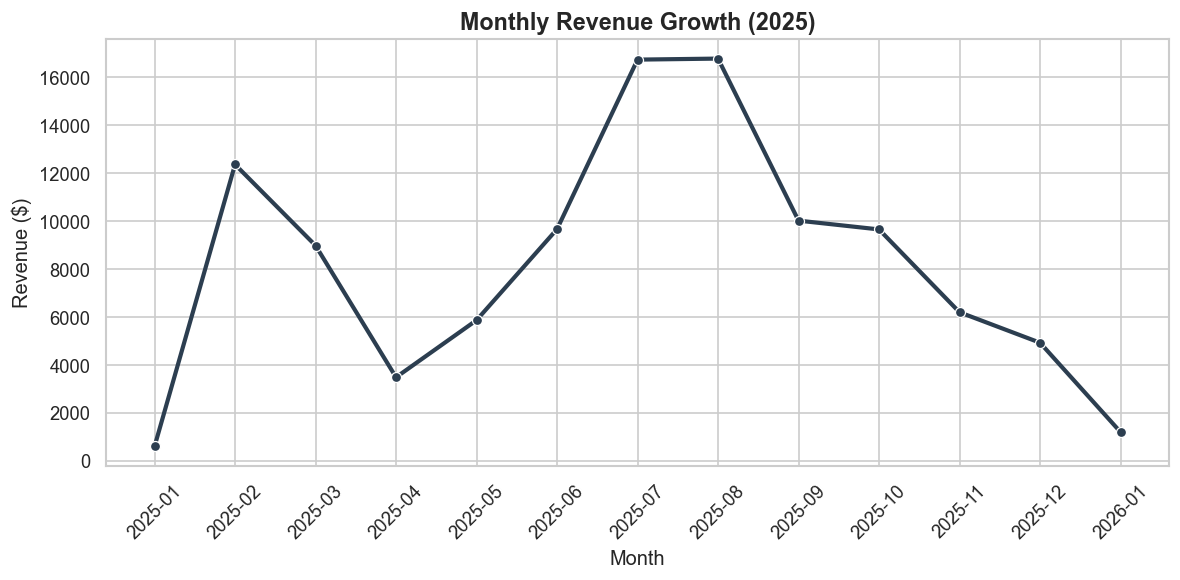


--- 2. Top Performing Categories ---


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,category_name,revenue
0,Home & Kitchen,115985.21
1,Clothing,108299.85
2,Books,107771.06
3,Electronics,89958.51
4,Sports,27929.39


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x='revenue', y='category_name', palette='viridis')


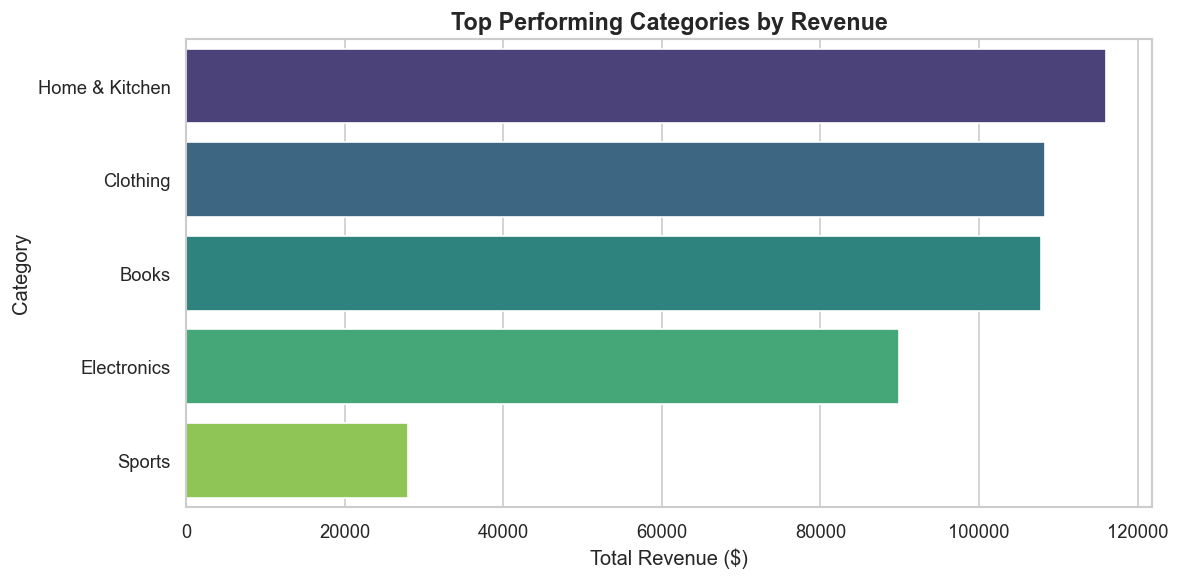


--- 3. Order Status Distribution ---


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,status,count
0,Shipped,38
1,Cancelled,34
2,Pending,37
3,Completed,42


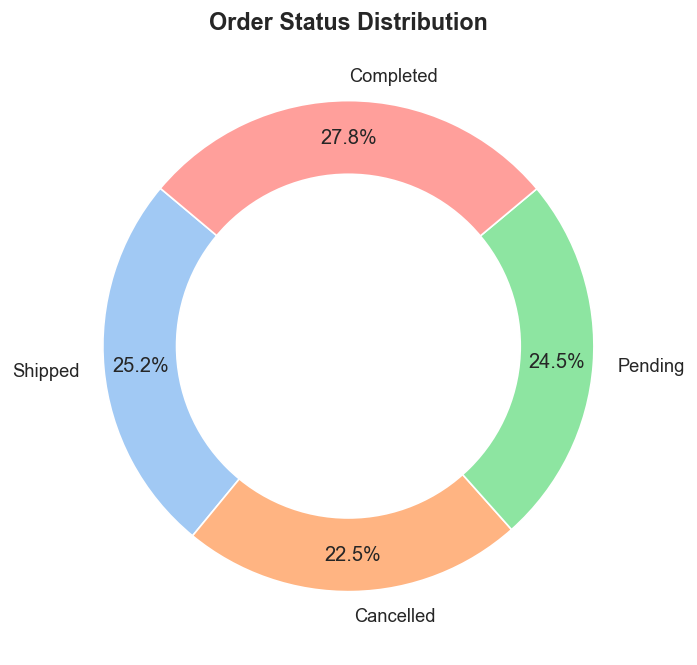


--- 4. VIP Customer Analysis (LTV) ---


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,first_name,LTV
0,Jon,8361.26
1,Richard,8312.35
2,Linda,7040.71
3,Allison,6063.37
4,Michael,5857.49


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13860\3123682790.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vip, x='first_name', y='LTV', palette='rocket')


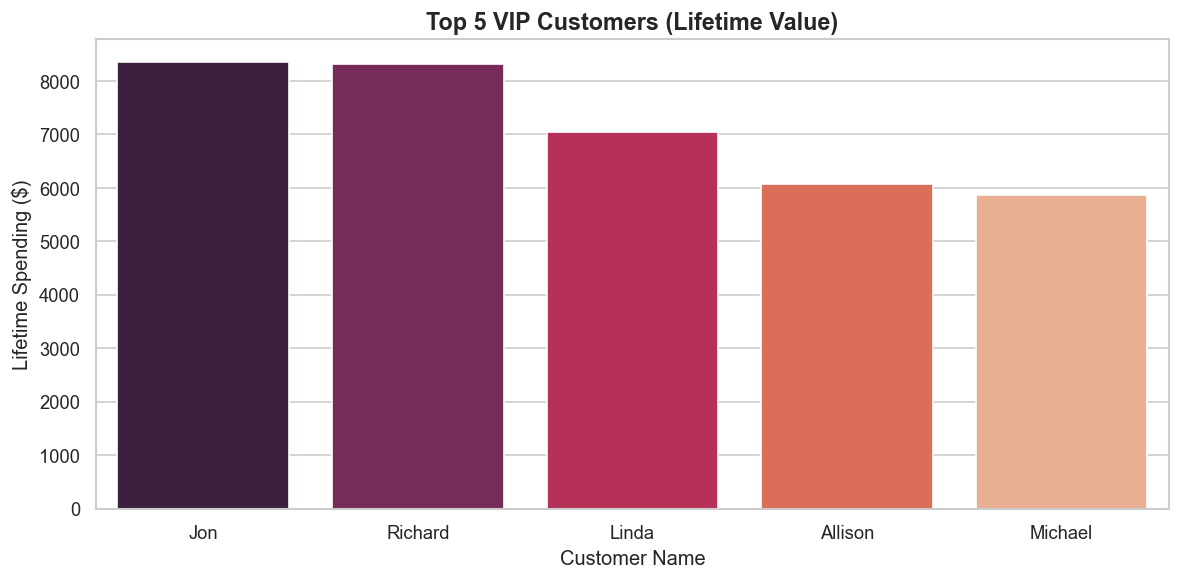

In [ ]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Explicitly import display for clarity

# --- 1. SETUP & CONNECTION ---
# Use a refined style for academic/professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

db_config = {
    'host': '*******',
    'user': '******',
    'password': '*******',
    'database': 'ecommerce_db'
}

def get_data(query):
    conn = mysql.connector.connect(**db_config)
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# --- 2. GENERATE PLOTS & TABLES ---

# FIGURE 1: Monthly Revenue Trend
print("--- 1. Monthly Revenue Data ---")
sql_revenue = """
SELECT DATE_FORMAT(order_date, '%Y-%m') AS month, SUM(total_amount) AS revenue 
FROM orders WHERE status = 'Completed' GROUP BY month ORDER BY month
"""
df_revenue = get_data(sql_revenue)
df_revenue = df_revenue.dropna() # Clean data

# Display the Table (GitHub will render this!)
display(df_revenue.head(10)) 

# Generate Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_revenue, x='month', y='revenue', marker='o', linewidth=2.5, color='#2c3e50')
plt.title("Monthly Revenue Growth (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# FIGURE 2: Category Performance
print("\n--- 2. Top Performing Categories ---")
sql_cat = """
SELECT c.category_name, SUM(oi.quantity * oi.unit_price) AS revenue
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN categories c ON p.category_id = c.category_id
GROUP BY c.category_name ORDER BY revenue DESC LIMIT 5
"""
df_cat = get_data(sql_cat)

# Display the Table
display(df_cat)

# Generate Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=df_cat, x='revenue', y='category_name', palette='viridis')
plt.title("Top Performing Categories by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Total Revenue ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# FIGURE 3: Operational Efficiency (Order Status)
print("\n--- 3. Order Status Distribution ---")
sql_status = "SELECT status, COUNT(*) as count FROM orders GROUP BY status"
df_status = get_data(sql_status)

# Display the Table
display(df_status)

# Generate Plot
plt.figure(figsize=(6, 6))
plt.pie(df_status['count'], labels=df_status['status'], autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Order Status Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# FIGURE 4: Top Customers (VIPs)
print("\n--- 4. VIP Customer Analysis (LTV) ---")
sql_vip = """
SELECT u.first_name, SUM(o.total_amount) as LTV
FROM users u JOIN orders o ON u.user_id = o.user_id
WHERE o.status = 'Completed'
GROUP BY u.user_id ORDER BY LTV DESC LIMIT 5
"""
df_vip = get_data(sql_vip)

# Display the Table
display(df_vip)

# Generate Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=df_vip, x='first_name', y='LTV', palette='rocket')
plt.title("Top 5 VIP Customers (Lifetime Value)", fontsize=14, fontweight='bold')
plt.xlabel("Customer Name")
plt.ylabel("Lifetime Spending ($)")
plt.tight_layout()
plt.show()

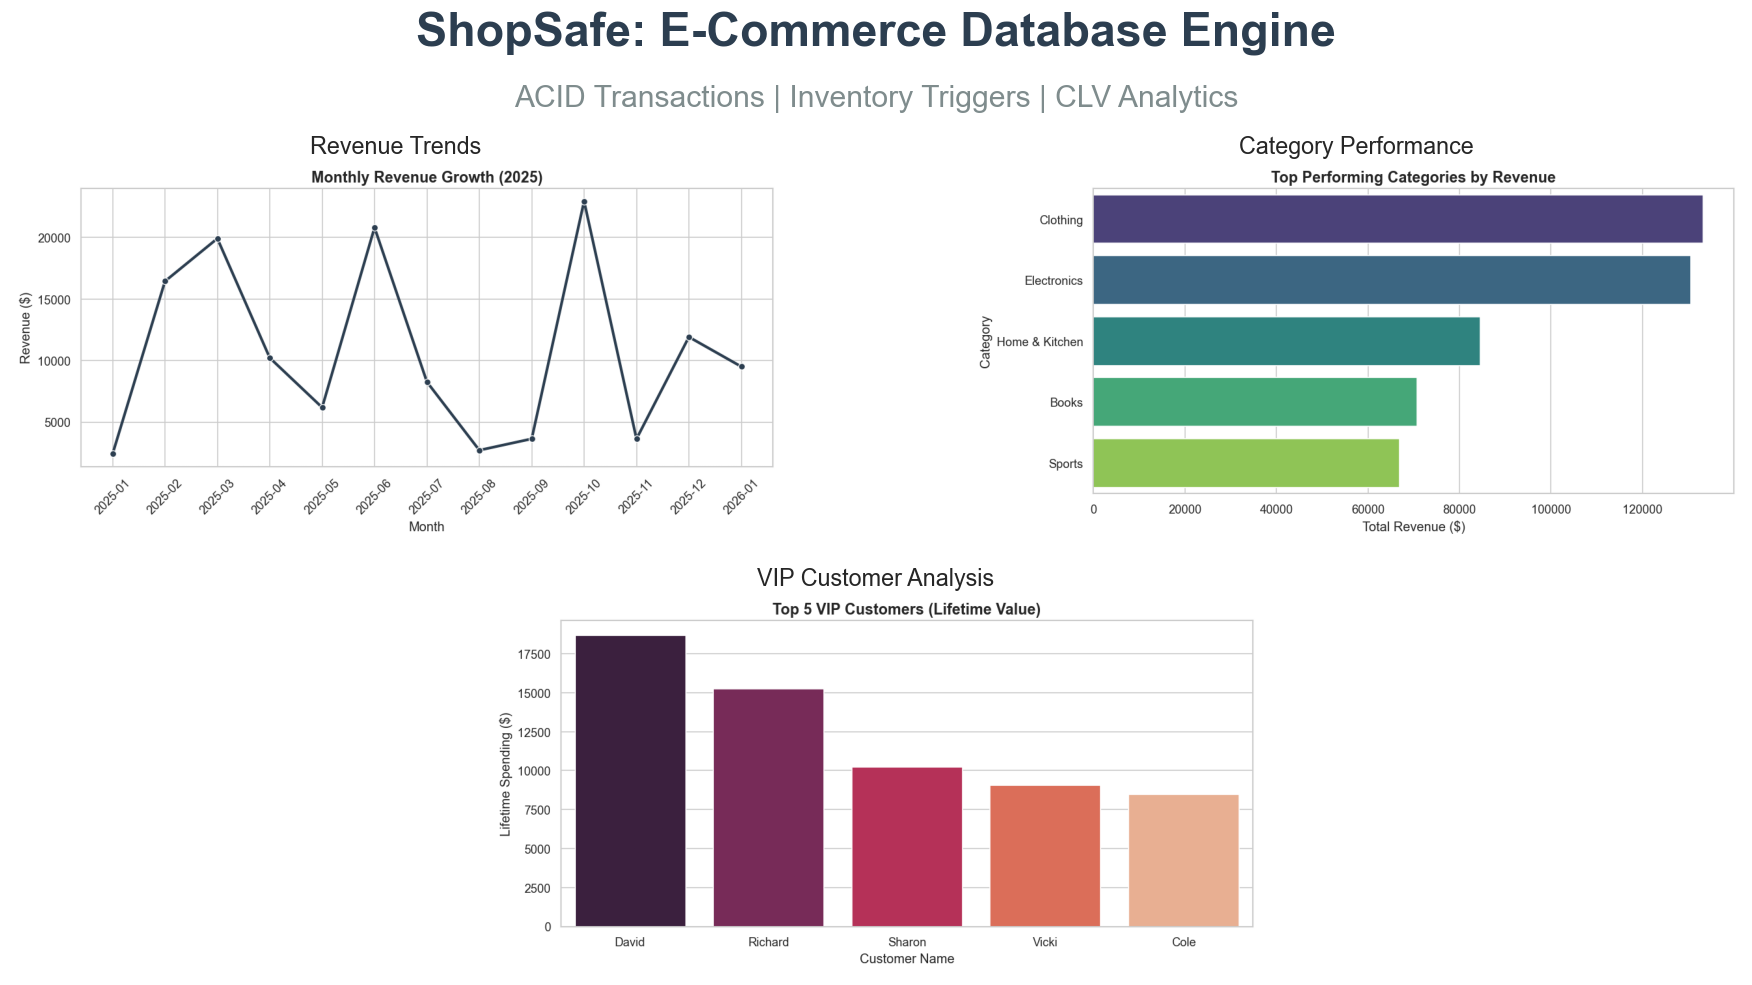

E-Commerce Cover Photo Saved as 'ecommerce_banner.png'


In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Create a figure for the banner (16:9 aspect ratio)
fig = plt.figure(figsize=(16, 9))
plt.axis('off') # Hide axes

# Define title
fig.text(0.5, 0.92, "ShopSafe: E-Commerce Database Engine", 
         ha='center', va='center', fontsize=28, fontweight='bold', color='#2c3e50')
fig.text(0.5, 0.86, "ACID Transactions | Inventory Triggers | CLV Analytics", 
         ha='center', va='center', fontsize=18, color='#7f8c8d')

# Load the images (Make sure these files exist in your folder!)
# These are the names we used in the E-Commerce Dashboard code
try:
    img1 = mpimg.imread('Fig_1.png') 
    img2 = mpimg.imread('Fig_2.png') 
    img3 = mpimg.imread('Fig_4.png') 

    # Create Subplots for the collage
    ax1 = fig.add_axes([0.05, 0.45, 0.40, 0.35]) # Top Left
    ax1.imshow(img1)
    ax1.axis('off')
    ax1.set_title("Revenue Trends", fontsize=14)

    ax2 = fig.add_axes([0.55, 0.45, 0.40, 0.35]) # Top Right
    ax2.imshow(img2)
    ax2.axis('off')
    ax2.set_title("Category Performance", fontsize=14)

    ax3 = fig.add_axes([0.30, 0.05, 0.40, 0.35]) # Bottom Center
    ax3.imshow(img3)
    ax3.axis('off')
    ax3.set_title("VIP Customer Analysis", fontsize=14)

    # Save the banner
    plt.savefig('ecommerce_banner.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("E-Commerce Cover Photo Saved as 'ecommerce_banner.png'")

except FileNotFoundError:
    print("Error: Could not find the graph images. Please run the dashboard cells above first.")